In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile 
from pathlib import Path
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [3]:
work_dir = os.getcwd()
work_dir

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [4]:
my_data_dir = '/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'
train_path = os.path.join(my_data_dir, 'train')
val_path = os.path.join(my_data_dir, 'val')
test_path = os.path.join(my_data_dir, 'test')
print (train_path)
print(os.path.exists(train_path))

/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
True


In [5]:
version = 'v1'
file_path = os.path.join('outputs',version)
if 'outputs' in os.listdir(work_dir) and version in os.listdir(os.path.join(work_dir, 'outputs')):
    print('Old version exsists can create a new one.')
    pass
else:
    os.makedirs(name=file_path)

Old version exsists can create a new one.


In [6]:
labels = os.listdir(train_path)
print(f"Project Labels: {labels}")

Project Labels: ['fractured', 'not fractured']


In [7]:
import joblib
version = 'v2'
file_path = f'/workspaces/XrayFractureClass/outputs/{version}'
Path(file_path).mkdir(parents= True, exist_ok= True)

image_shape = (224, 224, 3)
joblib.dump(value=image_shape, filename=os.path.join(file_path, 'image_shape.pkl'))
image_shape = joblib.load(filename=os.path.join(file_path,'image_shape.pkl'))
print (file_path)

/workspaces/XrayFractureClass/outputs/v2


* train - fractured: 4606 images
* train - not fractured: 4640 images
* val - fractured: 337 images
* val - not fractured: 492 images
* test - fractured: 238 images
* test - not fractured: 268 images




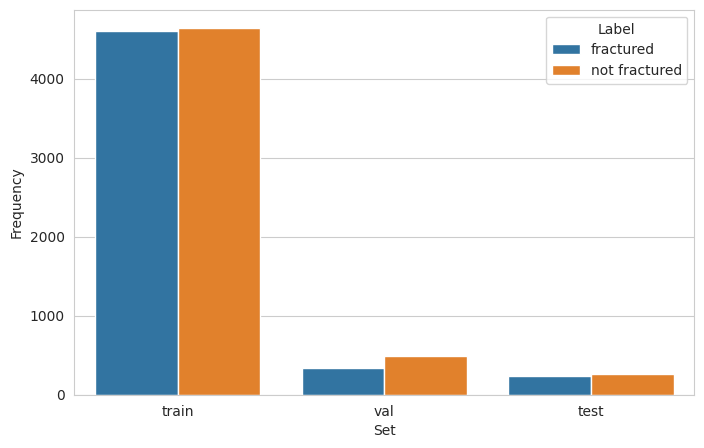

In [8]:
labels = ['fractured', 'not fractured']
df_freq = pd.DataFrame([])

for folder in ['train', 'val', 'test']:
    for label in labels:
        folder_path = os.path.join(my_data_dir, folder, label)
        freq = int(len(os.listdir(folder_path)))
        
        df_freq = pd.concat([df_freq, pd.DataFrame([{'Set': folder, 'Label': label, 'Frequency': freq}])  
        ], ignore_index = True)

        print(f"* {folder} - {label}: {freq} images")

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [9]:
augmented_image_data = ImageDataGenerator(rotation_range=20,width_shift_range=0.10, height_shift_range=0.10,shear_range=0.1,zoom_range=0.1,horizontal_flip=True,vertical_flip=True,fill_mode='nearest',rescale=1./255)

In [10]:
batch_size = 20  # This is the size of the batch
train_set = augmented_image_data.flow_from_directory(train_path, target_size=image_shape[:2],color_mode='rgb',batch_size=batch_size,class_mode='binary',shuffle=True)
train_set.class_indices
validation_set = ImageDataGenerator(rescale=1./255).flow_from_directory(val_path,target_size=image_shape[:2],color_mode='rgb',batch_size=batch_size,class_mode='binary',shuffle=False)
validation_set.class_indices
test_set = ImageDataGenerator(rescale=1./255).flow_from_directory(test_path,target_size=image_shape[:2], color_mode='rgb',batch_size=batch_size,class_mode='binary',shuffle=False)
test_set.class_indices

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

(20, 224, 224, 3)


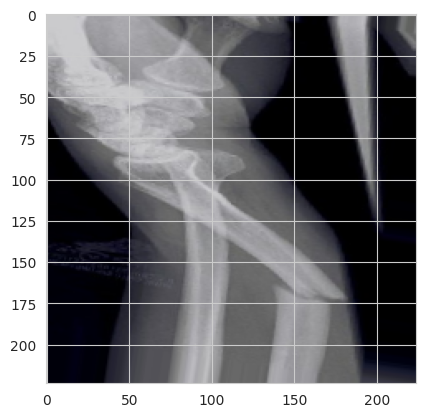

(20, 224, 224, 3)


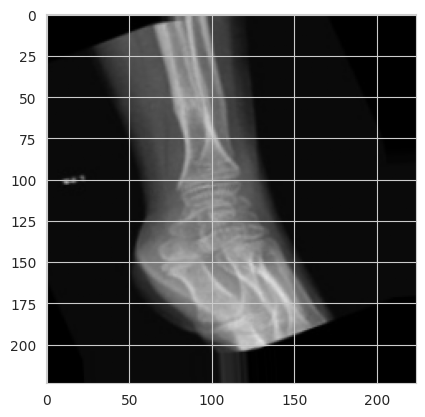

(20, 224, 224, 3)


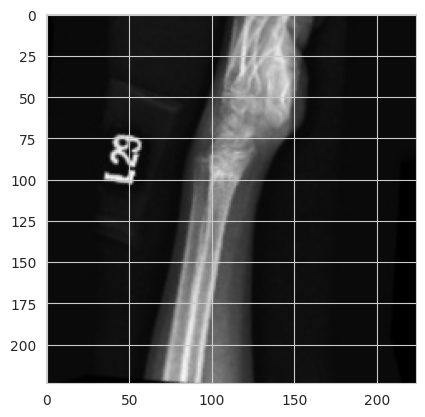

(20, 224, 224, 3)


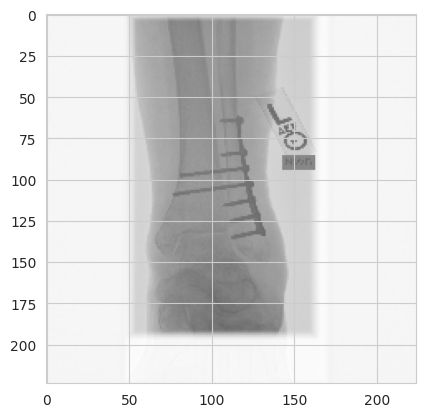

(20, 224, 224, 3)


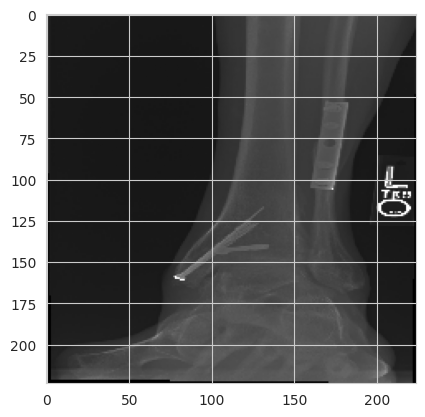

(20, 224, 224, 3)


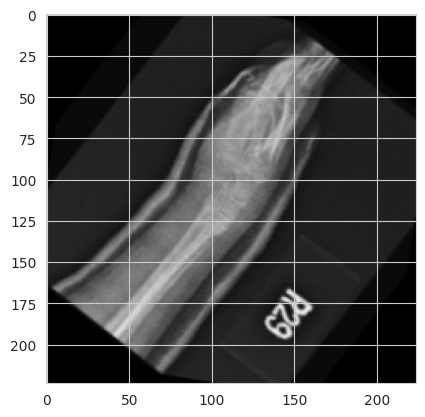

(20, 224, 224, 3)


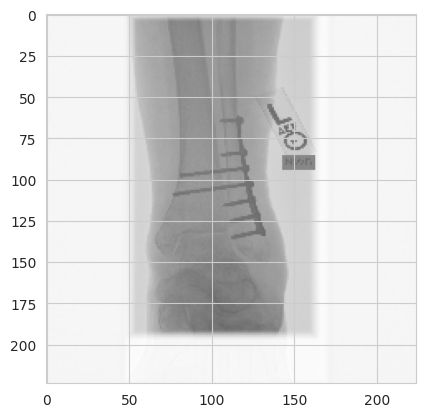

(20, 224, 224, 3)


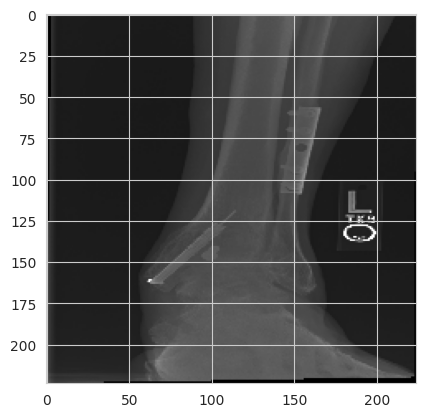

(20, 224, 224, 3)


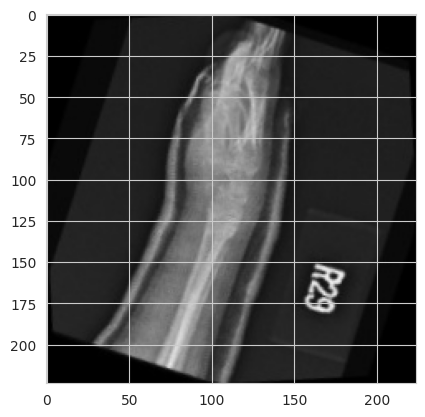

In [11]:
for _ in range(3):
    img, label = next (train_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()
for _ in range(3):
    img, label = next(validation_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()
for _ in range(3):
    img, label = next(test_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

In [12]:
joblib.dump(value=train_set.class_indices,filename=f"{file_path}/class_indices.pkl")

['/workspaces/XrayFractureClass/outputs/v2/class_indices.pkl']

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [14]:
def create_tf_model_v2(): #Creates model v2
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))    

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

In [15]:
create_tf_model_v2().summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
model_v2 = create_tf_model_v2()
model_v2.fit(train_set,epochs=8,steps_per_epoch=len(train_set.classes) // batch_size,validation_data=validation_set,callbacks=[early_stop],verbose=1)

import tensorflow as tf
model = tf.keras.models.load_model(f'{file_path_v2}/fracture_detection_model_v2.keras')
print('Model loaded successfully')

In [18]:
model_v2.save(f'{file_path}/fracture_detection_model_v2.keras')
print ('The model has been saved')

The model has been saved


In [ ]:
history = pd.DataFrame(model_v2.history.history)
history.head()

In [ ]:
sns.set_style("whitegrid")
history[['loss','val_loss']].plot(style='.-')
plt.title("Loss")
plt.show()

print("\n")
history[['accuracy','val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.show()

In [21]:
loss, accuracy = model_v2.evaluate(test_set)
print (f'Test Loss = :{loss:.4f}')
print (f'Test Accuracy = :{accuracy:.4f}')

I0000 00:00:1780004563.353479    3443 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 465ms/step - accuracy: 0.8221 - loss: 0.3642
Test Loss = :0.3642
Test Accuracy = :0.8221


Train Set

463/463 ━━━━━━━━━━━━━━━━━━━━ 164s 355ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                  1854                  2752
Predicted not fractured              1836                  2804


The Classification Report
               precision    recall  f1-score   support

    fractured       0.50      0.40      0.45      4606
not fractured       0.50      0.60      0.55      4640

     accuracy                           0.50      9246
    macro avg       0.50      0.50      0.50      9246
 weighted avg       0.50      0.50      0.50      9246
 



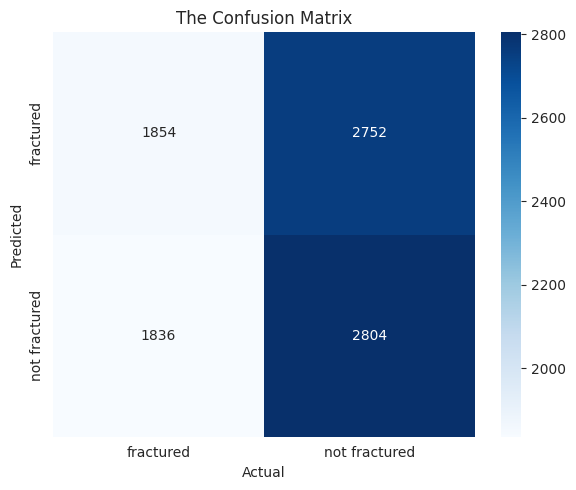

Validation Set 

12/42 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step

/usr/local/python/3.12.1/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 415ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                   255                    82
Predicted not fractured                29                   463


The Classification Report
               precision    recall  f1-score   support

    fractured       0.90      0.76      0.82       337
not fractured       0.85      0.94      0.89       492

     accuracy                           0.87       829
    macro avg       0.87      0.85      0.86       829
 weighted avg       0.87      0.87      0.86       829
 



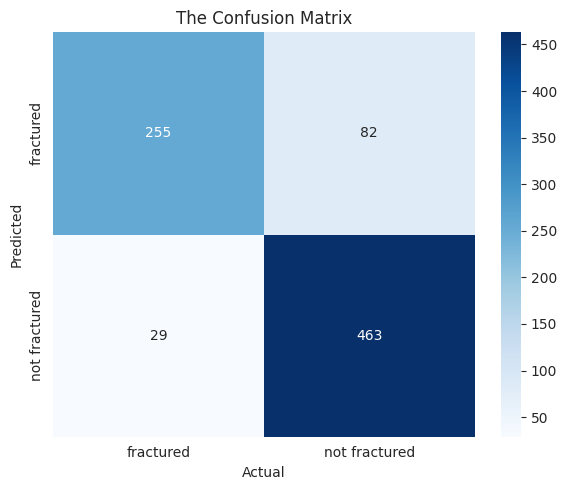

Test Set

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 323ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                   176                    62
Predicted not fractured                28                   240


The Classification Report
               precision    recall  f1-score   support

    fractured       0.86      0.74      0.80       238
not fractured       0.79      0.90      0.84       268

     accuracy                           0.82       506
    macro avg       0.83      0.82      0.82       506
 weighted avg       0.83      0.82      0.82       506
 



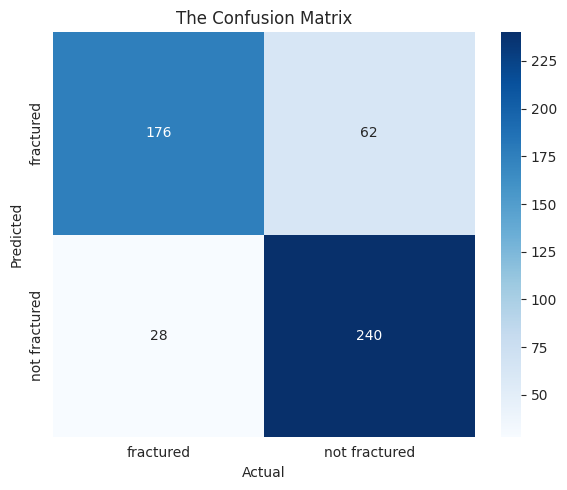

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def confusion_matrix_and_report(data_set, pipeline, label_map, set_name=''):
    data_set.reset()

    raw_predictions = pipeline.predict(data_set)
    class_predictions = (raw_predictions > 0.5). astype(int).flatten()
    class_true = data_set.classes
    confm = confusion_matrix(y_true=class_true, y_pred=class_predictions) # Computes the confusion matrix 

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confm,
        columns=["Actual " + sub for sub in label_map],
        index=["Predicted " + sub for sub in label_map]))
    
    print("\n")

    print('The Classification Report')
    print(classification_report(class_true, class_predictions, target_names=label_map),"\n")
    plt.figure(figsize=(6, 5))
    sns.heatmap(confm,annot=True,fmt='d',cmap='Blues',xticklabels=label_map,yticklabels=label_map)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('The Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(file_path, f'confusion_matrix_{set_name}.png'), bbox_inches = 'tight', dpi=150)
    plt.show()
    
def Model_performance_eval(train_set, validation_set, test_set, pipeline, label_map):
  print("Train Set\n")
  confusion_matrix_and_report(train_set, pipeline, label_map, 'Train set')
  print("Validation Set \n")
  confusion_matrix_and_report(validation_set, pipeline, label_map, 'Validation set')
  print("Test Set\n")
  confusion_matrix_and_report(test_set, pipeline, label_map, 'Test Set')

class_names = list(test_set.class_indices.keys())
Model_performance_eval( train_set, validation_set, test_set, model_v2, class_names)

(224, 224, 3)
0
This is 'fractured'


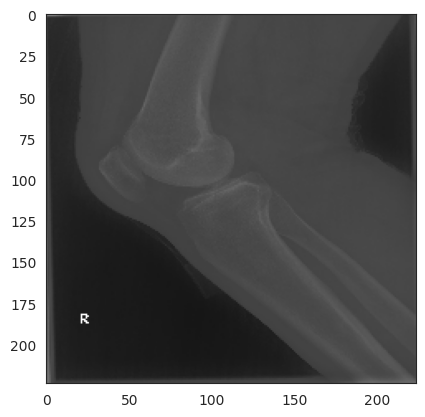

(224, 224, 3)

In [26]:
import tensorflow as tf
file_path = '/workspaces/XrayFractureClass/outputs/v2'
model_v2 = tf.keras.models.load_model(f'{file_path}/fracture_detection_model_v2.keras')


test_set.reset()
img_batch, label_batch = next(test_set)

index = 1
my_image = img_batch[index]
true_label = int(label_batch[index])
print(my_image.shape)
print(true_label)
print(f"This is '{class_names[true_label]}'")

sns.set_style('white')
plt.imshow(my_image)
plt.show()
my_image.shape